In [1]:
import torch
import numpy as np

import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from PIL import Image
from pyvirtualdisplay import Display
import gymnasium_robotics
import gymnasium as gym
import metaworld
gym.register_envs(gymnasium_robotics)

# os.environ["DISPLAY"] = "99"
rand_seed=123
device = torch.device(f"cuda:{1}" if torch.cuda.is_available() else "cpu")

In [6]:
data = torch.load("/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/faucet/faucet_dynamics_22/costs_rollout.pt")
data_np = data.cpu().numpy()
median = np.median(data_np, axis=1)
twentyfifth = np.percentile(data_np, 25, axis=1)
seventyfifth = np.percentile(data_np, 75, axis=1)

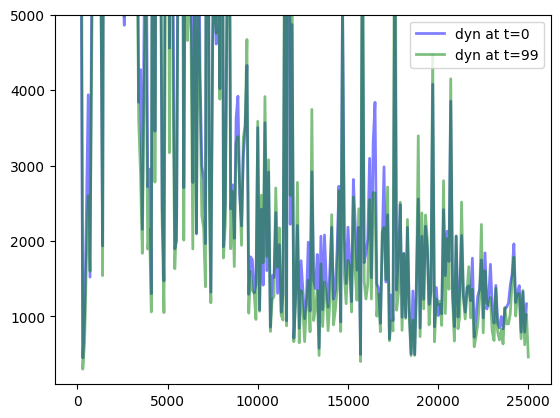

In [25]:
plot_start = 1000
plot_end = 25000
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter

# Gaussian filter (simple)
medians_smooth = gaussian_filter1d(median, sigma=2)
p25_smooth = gaussian_filter1d(twentyfifth, sigma=2)
p75_smooth = gaussian_filter1d(seventyfifth, sigma=2)

# medians_smooth = savgol_filter(median[plot_start:plot_end], window_length=11, polyorder=1)
# p25_smooth = savgol_filter(twentyfifth[plot_start:plot_end], window_length=11, polyorder=1)
# p75_smooth = savgol_filter(seventyfifth[plot_start:plot_end], window_length=11, polyorder=1)

# Plot smoothed data
fig, ax = plt.subplots()
x_vals = range(len(medians_smooth))
ax.plot(x_vals[::100], medians_smooth[::100], label='dyn at t=0', color='blue', linewidth=2, alpha=0.5)
ax.plot(x_vals[99::100], medians_smooth[99::100], label='dyn at t=99', color='green', linewidth=2, alpha=0.5)
# ax.fill_between(x_vals[::100], p25_smooth[::100], p75_smooth[::100], alpha=0.3, color='blue')
ax.set_ylim(100, 5000)
ax.legend()
plt.show()

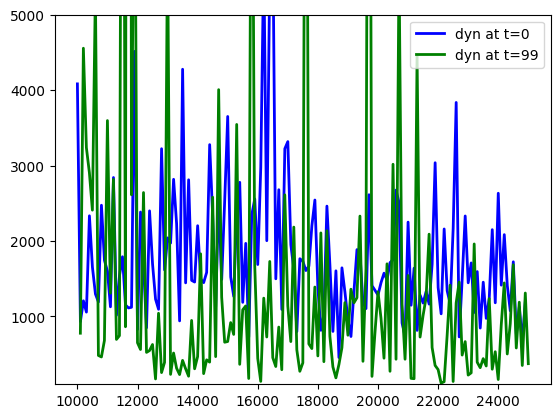

In [26]:
plot_start = 10000
plot_end = 25000
plot_every = 100
fig, ax = plt.subplots()
ax.plot(range(plot_start, plot_end)[::plot_every], median[plot_start:plot_end][::plot_every], label='dyn at t=0', color='blue', linewidth=2)
ax.plot(range(plot_start, plot_end)[99::plot_every], median[plot_start:plot_end][99::plot_every], label='dyn at t=99', color='green', linewidth=2)
# ax.fill_between(range(plot_start, plot_end), twentyfifth[plot_start:plot_end], seventyfifth[plot_start:plot_end], alpha=0.3, color='blue', label='25-75th percentile')
ax.set_ylim(100, 5000)
ax.legend()
plt.show()

In [2]:
import os
os.environ['MUJOCO_GL'] = 'egl'
# disp = Display(visible=0, size=(480, 480))
# disp.start()

/home/ayush/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:35: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
/home/ayush/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


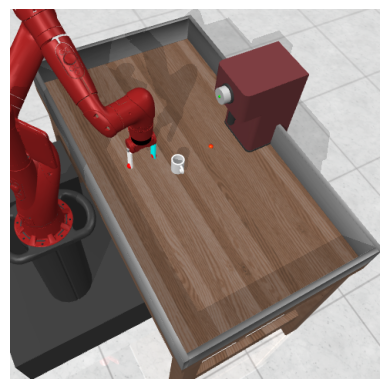

In [3]:
env = gym.make('Meta-World/MT1', env_name='coffee-push-v3', render_mode='rgb_array', camera_name='corner3')
obs, _ = env.reset()
img = env.render()
plt.imshow(np.rot90(img, k=2))
plt.axis('off')
plt.show()

In [1]:
import gymnasium as gym
import metaworld

env = gym.make('Meta-World/MT1', env_name='coffee-push-v3', render_mode='rgb_array', camera_name='corner3')
env.unwrapped.max_path_length = 1000
obs, _ = env.reset()
for t in range(500):
    action = env.action_space.sample()
    for _ in range(4):
        obs, reward, done, truncated, info = env.step(action)
    # img = env.render()
    # plt.imshow(np.rot90(img, k=2))
    # plt.axis('off')
    # plt.show()
    if done or truncated:
        if done:
            pass
        else:
            print('forced to truncate at time t=', t)
            obs, _ = env.reset()
            break

/home/ayush/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:35: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
/home/ayush/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/home/ayush/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


forced to truncate at time t= 124


  0%|          | 0/4 [00:00<?, ?it/s]

(400, 600, 3)
(400, 600, 3)
(400, 600, 3)


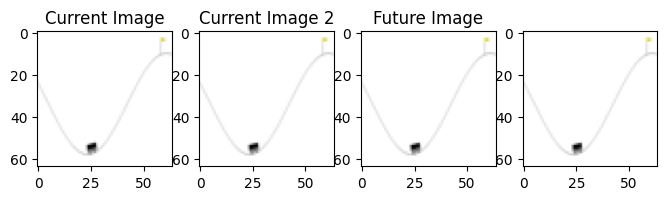

 75%|███████▌  | 3/4 [00:00<00:00, 20.28it/s]

(400, 600, 3)


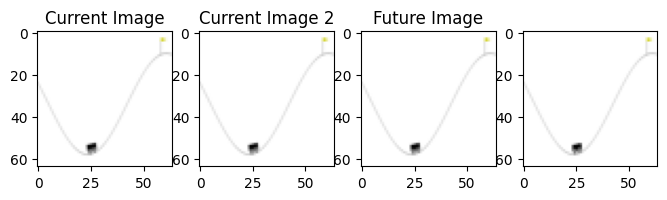

100%|██████████| 4/4 [00:00<00:00, 13.79it/s]

Failures (resets): 0


In [ ]:
env_name = "AntMaze_UMaze-v5" # agent centric view
env_name = "PointMaze_UMaze-v3"
env_name = "MountainCarContinuous-v0"
env = gym.make(env_name, render_mode="rgb_array") #, continuing_task=True)

num_prev = 3
data_length = num_prev + 1
obs, _ = env.reset(seed=rand_seed)

dataset = []  # List of (obs, action, image)
next_imgs = []
obs_arr = []
acts_arr = []

fail_counter = 0
for obs_counter in tqdm(range(data_length)):
    # if obs_counter + 3 >= data_length:
    #     break
    if len(next_imgs) == 0:
        rendered_img = env.render()
        # rendered_img = rendered_img[:, 50:-50, :] # Acrobot
        # rendered_img = rendered_img[100:-50, 100:-100, :]
        # rendered_img = rendered_img[110:-70, 20:-20, :]
        img_resize = Image.fromarray(rendered_img).resize((64, 64)) #.resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8))
        next_imgs.append(np.asarray(img_resize))
        obs_arr.append(obs.copy())

    act = env.action_space.sample()
    next_obs, rew, done, _, _ = env.step(act)
    acts_arr.append(act)
    
    if done:
        fail_counter += 1
        obs, _ = env.reset()
        next_imgs = []
        obs_arr = []
        acts_arr = []
    else:
        if len(next_imgs) == num_prev + 1:
            obs_arr.pop(0)
            next_imgs.pop(0)
            acts_arr.pop(0)
        next_img = env.render()
        # next_img = next_img[:, 50:-50, :] # [y dir, x dir, color]
        # next_img = next_img[100:-50, 100:-100, :] # [y dir, x dir, color]
        # next_img = next_img[100:-50, :-100, :]
        # next_img = next_img[110:-70, 20:-20, :]
        next_img = Image.fromarray(next_img).resize((64, 64)) #.resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8)).resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8))
        # next_img = Image.fromarray(next_img).resize((96, 96)) #.resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8)).resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8))
        next_imgs.append(np.asarray(next_img))
        obs_arr.append(next_obs.copy())
        
        if len(next_imgs) == num_prev + 1:
            
            fig, ax = plt.subplots(1, num_prev+1, figsize=(8, 10))
            ax[0].set_title("Current Image")
            ax[1].set_title("Current Image 2")
            ax[2].set_title("Future Image")
            for i, img in enumerate(next_imgs):
                ax[i].imshow(img)
                # ax[i].set_xlabel(np.array2string(obs_arr[i], formatter={'float_kind': lambda x: "%.2f" % x}))
            plt.show()
            plt.close(fig)
            # Store only valid transitions
            dataset.append({
                'obs': np.asarray(obs_arr).copy(),
                'action': np.asarray(acts_arr).copy(),
                'image': np.asarray(next_imgs[:-1]).copy(),
                'next_image': next_imgs[-1].copy()
            })
        obs = next_obs
print(f"Failures (resets): {fail_counter}")